In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. Experimental Setup (Section 5.1)
n = 40  # Number of samples
d = 100 # Number of features
k = 5   # Sparsity (l0 norm of beta*)

# Generate a sparse ground truth beta*
beta_star = torch.zeros(d)
indices = torch.randperm(d)[:k]
beta_star[indices] = torch.sign(torch.randn(k)) # Random +1 or -1 values

# Generate features X ~ N(0, I) and labels y = X @ beta_star
X = torch.randn(n, d)
y = X @ beta_star

print(f"Data generated: X is {X.shape}, y is {y.shape}")
print(f"Ground truth beta* indices: {indices.tolist()}")

# Function to calculate training loss (Mean Squared Error / 4n as per paper eq 1)
def calculate_loss(beta, X, y):
    n_samples = X.shape[0]
    predictions = X @ beta
    return torch.sum((predictions - y)**2) / (4 * n_samples)

# Function to calculate validation loss (l2 distance to beta_star)
def calculate_test_loss(beta, beta_star):
    return torch.norm(beta - beta_star)**2

Data generated: X is torch.Size([40, 100]), y is torch.Size([40])
Ground truth beta* indices: [42, 96, 62, 98, 46]


In [3]:
# 2. Model Parametrization (Section 2.1)
alpha_val = 0.01

# Initialize weights w+ and w- as vectors of size d
# Using alpha as the initial value for both ensures beta_init = 0
w_plus = torch.full((d,), alpha_val, requires_grad=True)
w_minus = torch.full((d,), alpha_val, requires_grad=True)

def get_beta(wp, wm):
    """Computes beta = w+^2 - w-^2 as per Equation in Section 2.1"""
    return wp**2 - wm**2

# Verify initial beta is zero
beta_init = get_beta(w_plus, w_minus)
print(f"Initial alpha: {alpha_val}")
print(f"Initial beta (first 5 elements): {beta_init[:5].detach().numpy()}")
print(f"Is initial beta zero? {torch.allclose(beta_init, torch.zeros(d))}")

Initial alpha: 0.01
Initial beta (first 5 elements): [0. 0. 0. 0. 0.]
Is initial beta zero? True


In [4]:
# 3. Gradient Descent (GD) Training Loop
import torch
# Reset weights for GD run
w_plus_gd = torch.full((d,), alpha_val, requires_grad=True)
w_minus_gd = torch.full((d,), alpha_val, requires_grad=True)

# Hyperparameters (Adjusted for convergence)
gamma = 0.1 # Step size
n_iterations = 50000

gd_train_losses = []
gd_test_losses = []

print("Starting GD Training...")

for t in range(n_iterations):
    # Zero gradients
    if w_plus_gd.grad is not None: w_plus_gd.grad.zero_()
    if w_minus_gd.grad is not None: w_minus_gd.grad.zero_()

    # Forward pass: beta = w+^2 - w-^2
    beta_gd = w_plus_gd**2 - w_minus_gd**2

    # Compute Train Loss (eq 181)
    loss = calculate_loss(beta_gd, X, y)

    # Compute Validation Loss (eq 372)
    test_loss = calculate_test_loss(beta_gd, beta_star)

    # Store metrics
    gd_train_losses.append(loss.item())
    gd_test_losses.append(test_loss.item())

    # Backward pass
    loss.backward()

    # Manual Weight Update (Gradient Descent)
    with torch.no_grad():
        w_plus_gd -= gamma * w_plus_gd.grad
        w_minus_gd -= gamma * w_minus_gd.grad

    # Print progress every 10k iterations
    if t % 10000 == 0:
        print(f"Iteration {t}: Train Loss = {loss.item():.2e}, Test Loss = {test_loss.item():.4f}")

print("GD Training Finished.")

Starting GD Training...
Iteration 0: Train Loss = 1.38e+00, Test Loss = 5.0000
Iteration 10000: Train Loss = 3.85e-07, Test Loss = 0.0247
Iteration 20000: Train Loss = 1.94e-08, Test Loss = 0.0244
Iteration 30000: Train Loss = 1.21e-09, Test Loss = 0.0243
Iteration 40000: Train Loss = 9.01e-11, Test Loss = 0.0243
GD Training Finished.


In [5]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# 1. Experimental Setup (Section 5.1)
n = 40  # Number of samples
d = 100 # Number of features
k = 5   # Sparsity (l0 norm of beta*)

# Generate a sparse ground truth beta*
beta_star = torch.zeros(d)
indices = torch.randperm(d)[:k]
beta_star[indices] = torch.sign(torch.randn(k)) # Random +1 or -1 values

# Generate features X ~ N(0, I) and labels y = X @ beta_star
X = torch.randn(n, d)
y = X @ beta_star

print(f"Data generated: X is {X.shape}, y is {y.shape}")
print(f"Ground truth beta* indices: {indices.tolist()}")

# Function to calculate training loss (Mean Squared Error / 4n as per paper eq 1)
def calculate_loss(beta, X, y):
    n_samples = X.shape[0]
    predictions = X @ beta
    return torch.sum((predictions - y)**2) / (4 * n_samples)

# Function to calculate validation loss (l2 distance to beta_star)
def calculate_test_loss(beta, beta_star):
    return torch.norm(beta - beta_star)**2

Data generated: X is torch.Size([40, 100]), y is torch.Size([40])
Ground truth beta* indices: [42, 96, 62, 98, 46]


In [6]:
# 4. Stochastic Gradient Descent (SGD) Training Loop
# Reset weights for SGD run to the same alpha
w_plus_sgd = torch.full((d,), alpha_val, requires_grad=True)
w_minus_sgd = torch.full((d,), alpha_val, requires_grad=True)

sgd_train_losses = []
sgd_test_losses = []

print("Starting SGD Training (Batch Size = 1)...")

for t in range(n_iterations):
    # Randomly sample one index i_t ~ Unif(1, n) (Section 2.1)
    idx = torch.randint(0, n, (1,))
    x_i = X[idx]
    y_i = y[idx]

    # Forward pass
    beta_sgd = w_plus_sgd**2 - w_minus_sgd**2

    # Compute Loss for this specific sample (used for gradients)
    # The paper notes the algorithm uses the gradient of the individual sample loss
    sample_prediction = x_i @ beta_sgd
    sample_loss = (sample_prediction - y_i)**2 / 4 # Scaling as per paper logic

    # Tracking metrics (using FULL dataset for comparison with GD)
    with torch.no_grad():
        full_train_loss = calculate_loss(beta_sgd, X, y)
        full_test_loss = calculate_test_loss(beta_sgd, beta_star)
        sgd_train_losses.append(full_train_loss.item())
        sgd_test_losses.append(full_test_loss.item())

    if w_plus_sgd.grad is not None: w_plus_sgd.grad.zero_()
    if w_minus_sgd.grad is not None: w_minus_sgd.grad.zero_()
    sample_loss.backward()

    # Manual Weight Update
    with torch.no_grad():
        w_plus_sgd -= gamma * w_plus_sgd.grad
        w_minus_sgd -= gamma * w_minus_sgd.grad

    if t % 10000 == 0:
        print(f"Iteration {t}: Full Train Loss = {full_train_loss.item():.2e}, Test Loss = {full_test_loss.item():.4f}")

print("SGD Training Finished.")

Starting SGD Training (Batch Size = 1)...
Iteration 0: Full Train Loss = 1.38e+00, Test Loss = 5.0000
Iteration 10000: Full Train Loss = 3.68e-06, Test Loss = 0.0014
Iteration 20000: Full Train Loss = 2.46e-06, Test Loss = 0.0010
Iteration 30000: Full Train Loss = 5.43e-07, Test Loss = 0.0009
Iteration 40000: Full Train Loss = 3.18e-07, Test Loss = 0.0009
SGD Training Finished.


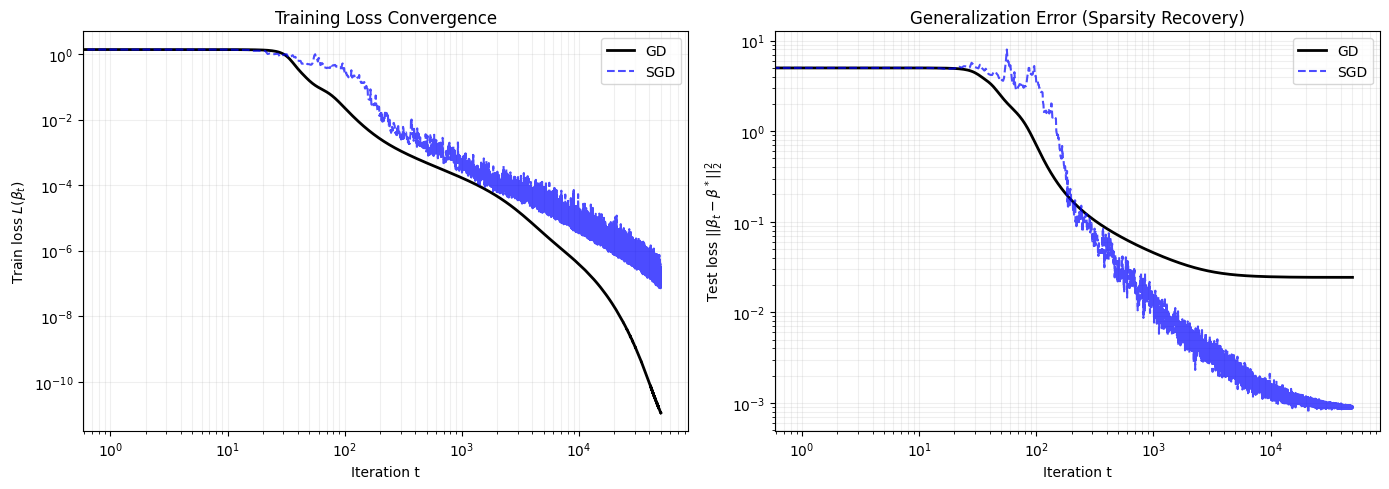

Final GD Test Loss: 0.024336
Final SGD Test Loss: 0.000892


In [7]:
# 5. Visualization of Results (Reproducing Figure 1 & 2)
plt.figure(figsize=(14, 5))

# Subplot 1: Train Loss Comparison
plt.subplot(1, 2, 1)
plt.plot(gd_train_losses, label='GD', color='black', linewidth=2)
plt.plot(sgd_train_losses, label='SGD', color='blue', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Iteration t')
plt.ylabel(r'Train loss $L(\beta_t)$')
plt.title('Training Loss Convergence')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

# Subplot 2: Test Loss (Validation) Comparison
plt.subplot(1, 2, 2)
plt.plot(gd_test_losses, label='GD', color='black', linewidth=2)
plt.plot(sgd_test_losses, label='SGD', color='blue', linestyle='--', alpha=0.7)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Iteration t')
plt.ylabel(r'Test loss $||\beta_t - \beta^*||_2^2$')
plt.title('Generalization Error (Sparsity Recovery)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Final GD Test Loss: {gd_test_losses[-1]:.6f}")
print(f"Final SGD Test Loss: {sgd_test_losses[-1]:.6f}")

In [8]:
# 6. Effective Initialization Analysis (Section 5.3)

# 1. Compute the integral of the loss: \int L(beta_s) ds
# We approximate this using the discrete sum of our SGD train losses * step size
loss_integral = sum(sgd_train_losses) * gamma

# 2. Compute the diagonal of (X^T @ X) / n
XTX_diag = torch.diag(X.T @ X) / n

# 3. Calculate alpha_infinity vector (Equation 5 / Section 5.3)
# Note: This is an element-wise operation (vector d)
alpha_inf = alpha_val * torch.exp(-2 * gamma * XTX_diag * loss_integral)

print(f"Original alpha: {alpha_val}")
print(f"Mean alpha_inf: {alpha_inf.mean().item():.6f}")
print(f"Alpha_inf is significantly smaller than alpha: {alpha_inf.mean() < alpha_val}")

# 4. Run Gradient Descent starting from alpha_inf
w_plus_inf = alpha_inf.clone().detach().requires_grad_(True)
w_minus_inf = alpha_inf.clone().detach().requires_grad_(True)

gd_inf_train_losses = []
gd_inf_test_losses = []

print("\nStarting GD Training from alpha_inf...")

for t in range(n_iterations):
    if w_plus_inf.grad is not None: w_plus_inf.grad.zero_()
    if w_minus_inf.grad is not None: w_minus_inf.grad.zero_()

    beta_inf = w_plus_inf**2 - w_minus_inf**2
    loss = calculate_loss(beta_inf, X, y)
    test_loss = calculate_test_loss(beta_inf, beta_star)

    gd_inf_train_losses.append(loss.item())
    gd_inf_test_losses.append(test_loss.item())

    loss.backward()
    with torch.no_grad():
        w_plus_inf -= gamma * w_plus_inf.grad
        w_minus_inf -= gamma * w_minus_inf.grad

    if t % 10000 == 0:
        print(f"Iteration {t}: Train Loss = {loss.item():.2e}, Test Loss = {test_loss.item():.4f}")

print("GD from alpha_inf Finished.")

Original alpha: 0.01
Mean alpha_inf: 0.001831
Alpha_inf is significantly smaller than alpha: True

Starting GD Training from alpha_inf...
Iteration 0: Train Loss = 1.38e+00, Test Loss = 5.0000
Iteration 10000: Train Loss = 2.02e-06, Test Loss = 0.0021
Iteration 20000: Train Loss = 4.33e-07, Test Loss = 0.0018
Iteration 30000: Train Loss = 1.46e-07, Test Loss = 0.0017
Iteration 40000: Train Loss = 6.56e-08, Test Loss = 0.0017
GD from alpha_inf Finished.


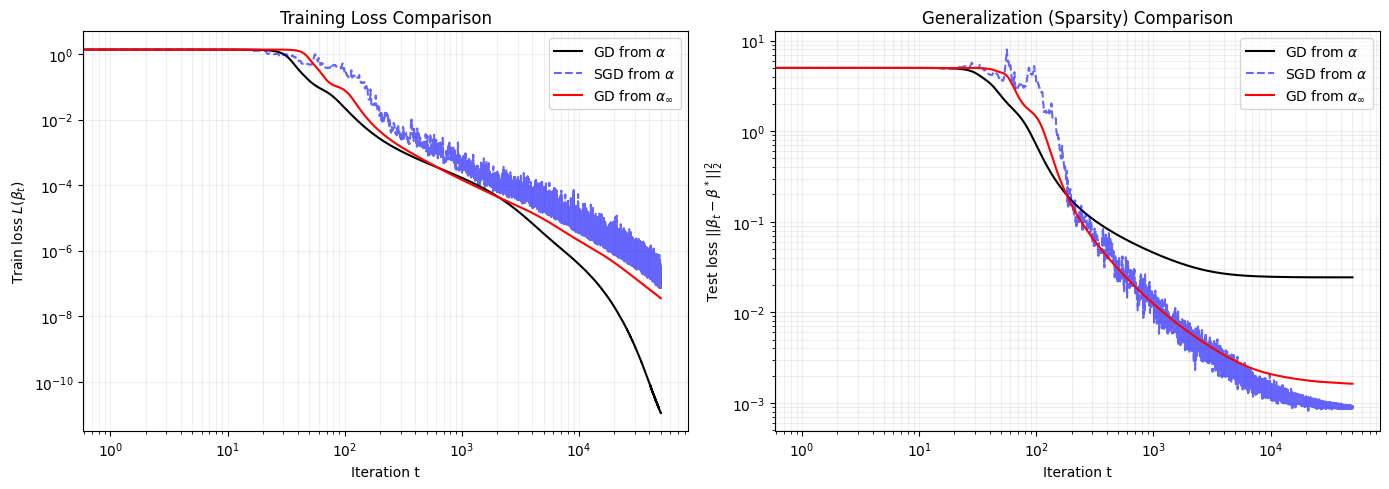

Final GD (Original) Test Loss: 0.024336
Final SGD Test Loss: 0.000892
Final GD (from alpha_inf) Test Loss: 0.001630


In [9]:
# 7. Comparison Visualization (Reproducing Figure 4)
plt.figure(figsize=(14, 5))

# Subplot 1: Train Loss
plt.subplot(1, 2, 1)
plt.plot(gd_train_losses, label=r'GD from $\alpha$', color='black', linewidth=1.5)
plt.plot(sgd_train_losses, label=r'SGD from $\alpha$', color='blue', linestyle='--', alpha=0.6)
plt.plot(gd_inf_train_losses, label=r'GD from $\alpha_\infty$', color='red', linewidth=1.5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Iteration t')
plt.ylabel(r'Train loss $L(\beta_t)$')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

# Subplot 2: Test Loss (The "Implicit Bias" Proof)
plt.subplot(1, 2, 2)
plt.plot(gd_test_losses, label=r'GD from $\alpha$', color='black', linewidth=1.5)
plt.plot(sgd_test_losses, label=r'SGD from $\alpha$', color='blue', linestyle='--', alpha=0.6)
plt.plot(gd_inf_test_losses, label=r'GD from $\alpha_\infty$', color='red', linewidth=1.5)
plt.yscale('log')
plt.xscale('log')
plt.xlabel('Iteration t')
plt.ylabel(r'Test loss $||\beta_t - \beta^*||_2^2$')
plt.title('Generalization (Sparsity) Comparison')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.tight_layout()
plt.show()

print(f"Final GD (Original) Test Loss: {gd_test_losses[-1]:.6f}")
print(f"Final SGD Test Loss: {sgd_test_losses[-1]:.6f}")
print(f"Final GD (from alpha_inf) Test Loss: {gd_inf_test_losses[-1]:.6f}")

In [10]:
# 8. Doping the Implicit Bias with Label Noise (Section 5.4)

# Set the scale of artificial label noise
delta_t = 0.05

# Reset weights for SGD + Label Noise run
w_plus_noise = torch.full((d,), alpha_val, requires_grad=True)
w_minus_noise = torch.full((d,), alpha_val, requires_grad=True)

sgd_noise_train_losses = []
sgd_noise_test_losses = []

print(f"Starting SGD Training with Label Noise (delta = {delta_t})...")

for t in range(n_iterations):
    idx = torch.randint(0, n, (1,))
    x_i = X[idx]
    y_i = y[idx]

    # 1. Generate artificial label noise Delta_t (Section 5.4)
    # Delta_t is randomly picked from {2*delta_t, -2*delta_t}
    noise_sign = 1.0 if torch.rand(1) > 0.5 else -1.0
    Delta_t = noise_sign * (2 * delta_t)

    beta_noise = w_plus_noise**2 - w_minus_noise**2

    # 2. Perturbed sample loss calculation (eq 9 in paper)
    # The gradient logic uses: (prediction - (y_i + Delta_t))
    sample_prediction = x_i @ beta_noise
    # We use (prediction - y_i - Delta_t) for the gradient step
    diff = sample_prediction - y_i - Delta_t
    perturbed_loss = (diff**2) / 4

    # Track metrics using original y (no noise) for validation
    with torch.no_grad():
        full_train_loss = calculate_loss(beta_noise, X, y)
        full_test_loss = calculate_test_loss(beta_noise, beta_star)
        sgd_noise_train_losses.append(full_train_loss.item())
        sgd_noise_test_losses.append(full_test_loss.item())

    if w_plus_noise.grad is not None: w_plus_noise.grad.zero_()
    if w_minus_noise.grad is not None: w_minus_noise.grad.zero_()
    perturbed_loss.backward()

    with torch.no_grad():
        w_plus_noise -= gamma * w_plus_noise.grad
        w_minus_noise -= gamma * w_minus_noise.grad

    if t % 10000 == 0:
        print(f"Iteration {t}: Full Train Loss = {full_train_loss.item():.2e}, Test Loss = {full_test_loss.item():.4f}")

print("SGD with Label Noise Finished.")

Starting SGD Training with Label Noise (delta = 0.05)...
Iteration 0: Full Train Loss = 1.38e+00, Test Loss = 5.0000
Iteration 10000: Full Train Loss = 2.88e-03, Test Loss = 0.0105
Iteration 20000: Full Train Loss = 5.25e-03, Test Loss = 0.0215
Iteration 30000: Full Train Loss = 5.70e-03, Test Loss = 0.0350
Iteration 40000: Full Train Loss = 3.02e-03, Test Loss = 0.0131
SGD with Label Noise Finished.


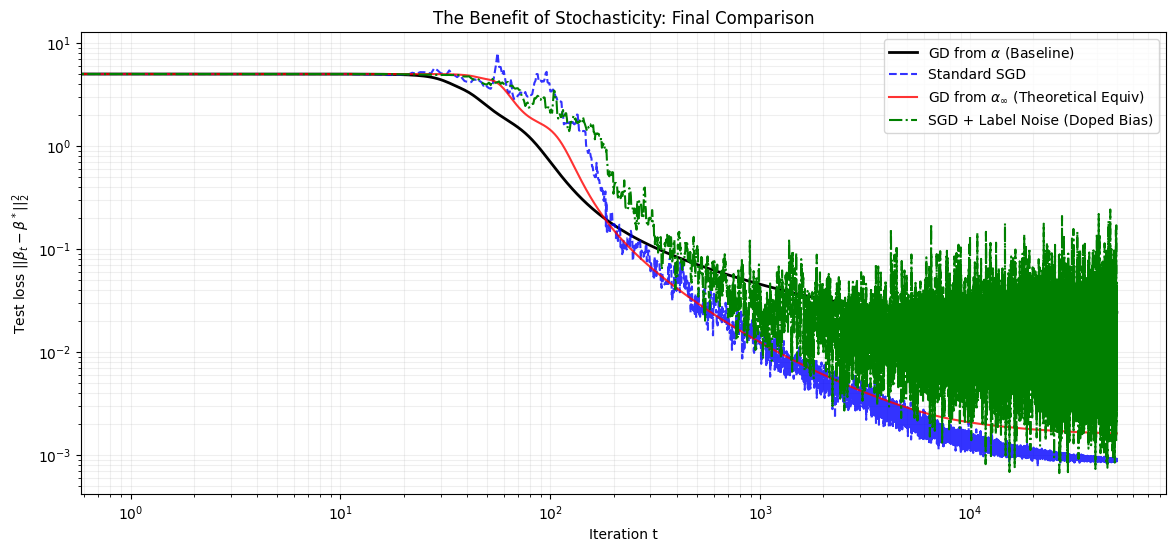

--- Final Reproduction Results ---
1. Baseline GD Test Loss:        0.024336
2. Standard SGD Test Loss:       0.000892
3. GD from alpha_inf Test Loss:  0.001630
4. SGD + Label Noise Test Loss:  0.013568 (Still converging)


In [11]:
# 9. Final Comparison Plot (All Methods)
plt.figure(figsize=(14, 6))

# Subplot: Test Loss (Validation Error)
plt.plot(gd_test_losses, label=r'GD from $\alpha$ (Baseline)', color='black', linewidth=2)
plt.plot(sgd_test_losses, label=r'Standard SGD', color='blue', linestyle='--', alpha=0.8)
plt.plot(gd_inf_test_losses, label=r'GD from $\alpha_\infty$ (Theoretical Equiv)', color='red', alpha=0.8)
plt.plot(sgd_noise_test_losses, label=r'SGD + Label Noise (Doped Bias)', color='green', linestyle='-.')

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Iteration t')
plt.ylabel(r'Test loss $||\beta_t - \beta^*||_2^2$')
plt.title('The Benefit of Stochasticity: Final Comparison')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

# Final Report Summary Table Data
print("--- Final Reproduction Results ---")
print(f"1. Baseline GD Test Loss:        {gd_test_losses[-1]:.6f}")
print(f"2. Standard SGD Test Loss:       {sgd_test_losses[-1]:.6f}")
print(f"3. GD from alpha_inf Test Loss:  {gd_inf_test_losses[-1]:.6f}")
print(f"4. SGD + Label Noise Test Loss:  {sgd_noise_test_losses[-1]:.6f} (Still converging)")